In [1]:
#import and formatting statements

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations
import numpy as np
import scikit_posthocs as sp


plt.rcParams['pdf.fonttype'] = 42
sns.set(style="whitegrid", context="talk")

# === Load data ===
file_path = "Source_Data_CXCL12_placenta.xlsx"
df = pd.read_excel(file_path, sheet_name = "Fig_3H+J")

<h2> Figure 3H </h2>

/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_97856/2573652899.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_97856/2573652899.py:12: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.8`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


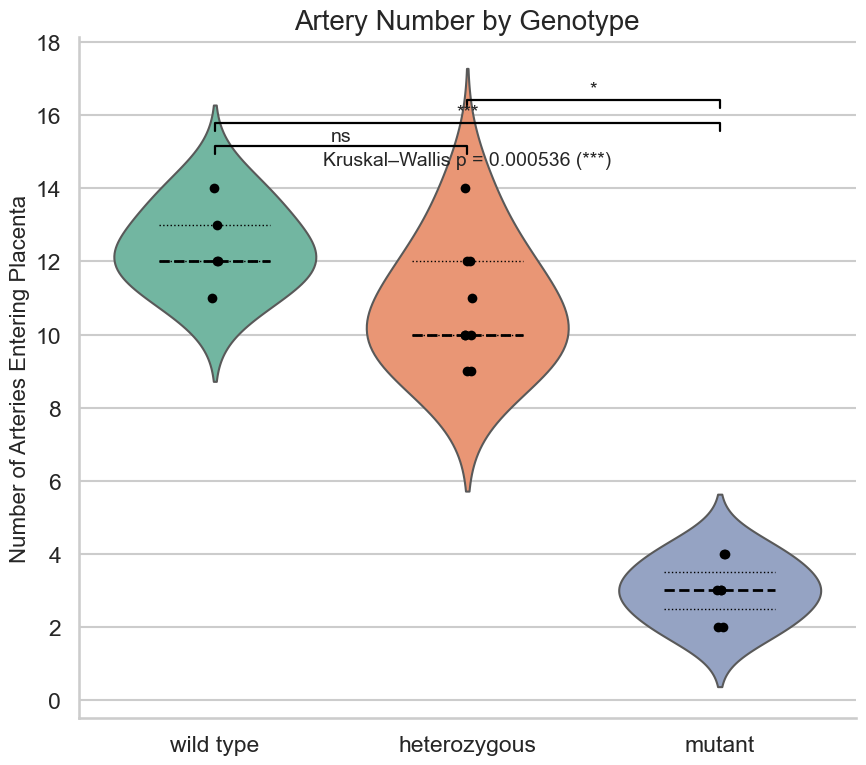

In [2]:
genotype_order = ["wild type", "heterozygous", "mutant"]
df["genotype"] = pd.Categorical(df["genotype"], categories=genotype_order, ordered=True)
plot_data = df[["genotype", "artery number entering placenta"]].dropna()

palette = sns.color_palette("Set2", len(genotype_order))


plt.figure(figsize=(9, 8))
ax = plt.gca()


sns.violinplot(
    data=plot_data,
    x="genotype",
    y="artery number entering placenta",
    order=genotype_order,
    inner=None,             
    linewidth=1.5,
    bw=0.8,                 
    cut=2.5,                
    palette=palette,
    ax=ax
)

group_stats = (
    plot_data.groupby("genotype")["artery number entering placenta"]
    .agg(["median", "quantile"])
)

for i, g in enumerate(genotype_order):
    vals = plot_data.loc[plot_data["genotype"] == g, "artery number entering placenta"]
    median = vals.median()
    q1 = vals.quantile(0.25)
    q3 = vals.quantile(0.75)

    ax.hlines(
        median, i - 0.22, i + 0.22,
        colors="black",
        linestyles="dashed",
        linewidth=2,
        zorder=5
    )

    ax.hlines(
        [q1, q3], i - 0.22, i + 0.22,
        colors="black",
        linestyles="dotted",
        linewidth=1.,
        zorder=5
    )

sns.stripplot(
    data=plot_data,
    x="genotype",
    y="artery number entering placenta",
    order=genotype_order,
    color="black",
    size=7,
    jitter=0.02,
    zorder=6,
    ax=ax
)


ax.set_xlabel("")
ax.set_ylabel("Number of Arteries Entering Placenta", fontsize=16)
ax.set_title("Artery Number by Genotype", fontsize=20)
sns.despine()
import matplotlib.ticker as mtick

ax.yaxis.set_major_locator(mtick.MaxNLocator(integer=True))

#kruskall-wallis
groups = [plot_data.loc[plot_data["genotype"] == g, "artery number entering placenta"]
          for g in genotype_order]
kw_stat, kw_p = kruskal(*groups)

if kw_p < 0.001:
    global_stars = "***"
elif kw_p < 0.01:
    global_stars = "**"
elif kw_p < 0.05:
    global_stars = "*"
else:
    global_stars = "ns"

ymax = plot_data["artery number entering placenta"].max()
offset = ymax * 0.15

ax.text(
    1,
    ymax + offset * 0.25,
    f"Kruskal–Wallis p = {kw_p:.3g} ({global_stars})",
    ha='center', va='bottom', fontsize=14
)

# dunn posthoc Bonferroni correction
dunn = sp.posthoc_dunn(
    plot_data,
    val_col="artery number entering placenta",
    group_col="genotype",
    p_adjust="bonferroni"
)

pairs = list(combinations(genotype_order, 2))
current_height = ymax + offset * 0.45
step = offset * 0.30

for (g1, g2) in pairs:
    pval = dunn.loc[g1, g2]

    if pval < 0.001:
        stars = "***"
    elif pval < 0.01:
        stars = "**"
    elif pval < 0.05:
        stars = "*"
    else:
        stars = "ns"

    x1 = genotype_order.index(g1)
    x2 = genotype_order.index(g2)

    ax.plot(
        [x1, x1, x2, x2],
        [current_height,
         current_height + offset * 0.1,
         current_height + offset * 0.1,
         current_height],
        color="black",
        lw=1.6
    )

    ax.text(
        (x1 + x2) / 2,
        current_height + offset * 0.12,
        stars,
        ha='center', va='bottom', fontsize=14
    )

    current_height += step

plt.tight_layout()
plt.show()


<h2> Figure 3J</h2>

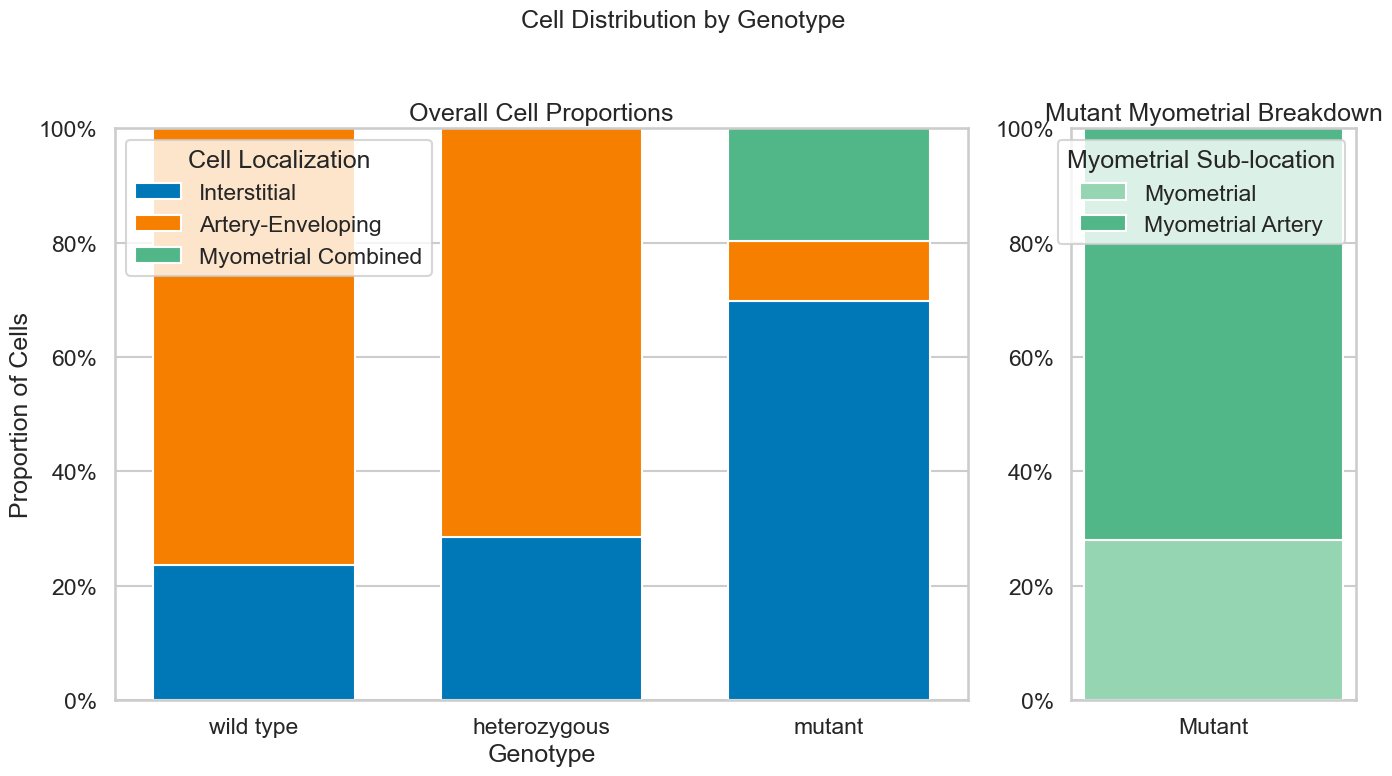

In [3]:
myometrial_sub_cols = [
    'myometrial',
    'myometrial artery',
]

df['myometrial_combined'] = df[myometrial_sub_cols].sum(axis=1)

agg_df = df.groupby('genotype')[[
    'interstitial',
    'artery-enveloping',
    'myometrial_combined',
    'myometrial', 
    'myometrial artery',
]].sum()

colors = {
    'interstitial': '#0077b6',
    'artery-enveloping': '#f77f00',
    'myometrial_combined': '#52b788',
    'myometrial': '#95d5b2',
    'myometrial artery': '#52b788',
}


fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 8),
    gridspec_kw={'width_ratios': [3, 1]}
)
fig.suptitle('Cell Distribution by Genotype', fontsize=18)



main_cols = ['interstitial', 'artery-enveloping', 'myometrial_combined']
agg_df['total_cells'] = agg_df[main_cols].sum(axis=1)
proportions = agg_df[main_cols].div(agg_df['total_cells'], axis=0)

genotype_order = ['wild type', 'heterozygous', 'mutant']
proportions = proportions.loc[genotype_order]

bottom = np.zeros(len(proportions))
for col in main_cols:
    ax1.bar(
        proportions.index,
        proportions[col],
        bottom=bottom,
        label=col.replace('_', ' ').title(),
        color=colors[col],
        width=0.7
    )
    bottom += proportions[col]

ax1.set_title('Overall Cell Proportions')
ax1.set_ylabel('Proportion of Cells')
ax1.set_xlabel('Genotype')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax1.set_ylim(0, 1)
ax1.legend(title='Cell Localization')



# isolate  mutant data
mutant_data = agg_df.loc['mutant']

myo_total_mutant = mutant_data['myometrial_combined']
mutant_myo_proportions = mutant_data[myometrial_sub_cols] / myo_total_mutant

bottom2 = 0
for col, val in mutant_myo_proportions.items():
    ax2.bar(
        'Mutant', 
        val,
        bottom=bottom2,
        label=col.replace('_', ' ').title(),
        color=colors[col],
        width=0.5
    )
    bottom2 += val

ax2.set_title('Mutant Myometrial Breakdown')
ax2.set_xlabel('')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', bottom=False) 
ax2.legend(title='Myometrial Sub-location')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

<h2>  Individual placenta values </h2>

/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_97856/306607140.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_97856/306607140.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_97856/306607140.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_97856/306607140.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

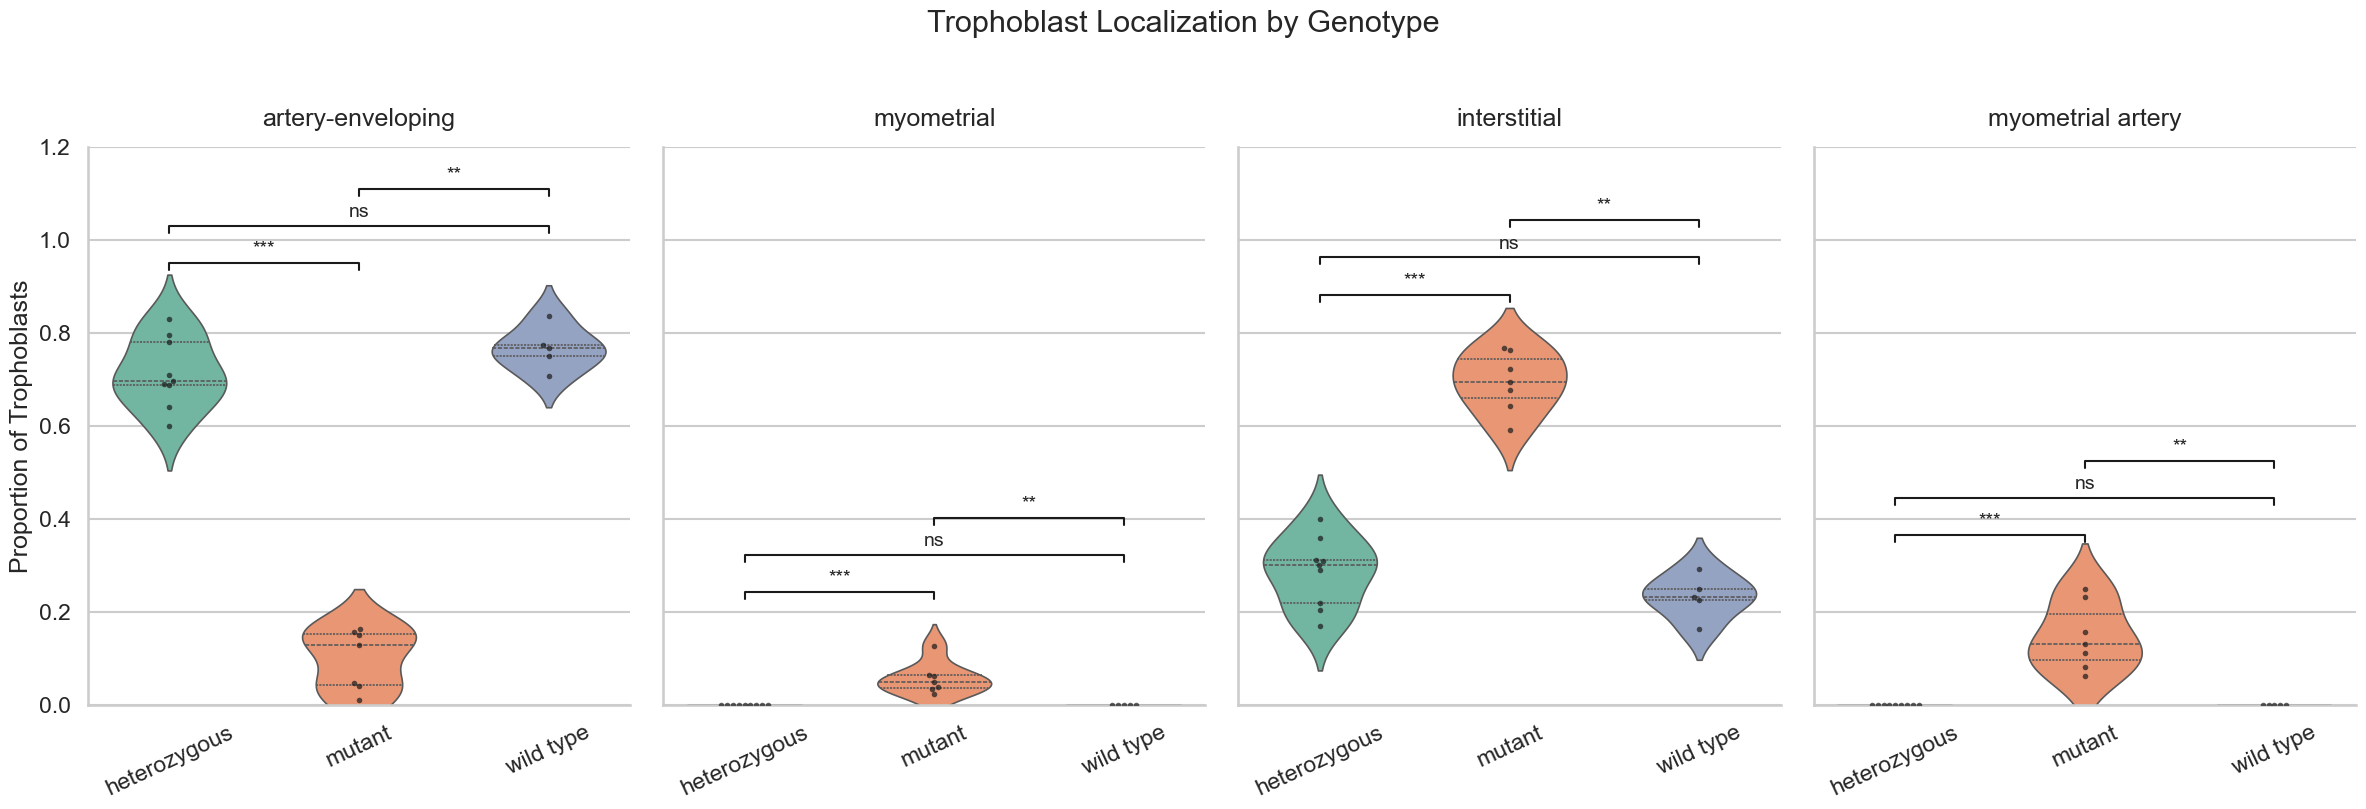

In [4]:
id_col = df.columns[0]
genotype_col = df.columns[1]
tropho_cols = df.columns[2:6]

df["total_trophoblasts"] = df[tropho_cols].sum(axis=1)
for col in tropho_cols:
    df[f"{col}_prop"] = df[col] / df["total_trophoblasts"]

prop_cols = [f"{col}_prop" for col in tropho_cols]
df_long = df.melt(
    id_vars=[id_col, genotype_col],
    value_vars=prop_cols,
    var_name="Trophoblast_Location",
    value_name="Proportion"
)
df_long["Trophoblast_Location"] = df_long["Trophoblast_Location"].str.replace("_prop", "", regex=False)

genotype_order = df[genotype_col].unique()
palette = sns.color_palette("Set2", len(genotype_order))

locations = df_long["Trophoblast_Location"].unique()
n_locs = len(locations)

fig, axes = plt.subplots(1, n_locs, figsize=(6 * n_locs, 8), sharey=True)
if n_locs == 1:
    axes = [axes]

for ax, loc in zip(axes, locations):
    data_sub = df_long[df_long["Trophoblast_Location"] == loc]

    sns.violinplot(
        data=data_sub,
        x=genotype_col,
        y="Proportion",
        palette=palette,
        order=genotype_order,
        inner="quartile",
        cut=2,
        linewidth=1.2,
        width=0.6,
        ax=ax
    )
    sns.swarmplot(
        data=data_sub,
        x=genotype_col,
        y="Proportion",
        color="k",
        size=4,
        alpha=0.7,
        order=genotype_order,
        ax=ax
    )

    ax.set_title(loc.replace("_", " "), fontsize=18, pad=15)
    ax.set_xlabel("")
    ax.set_ylabel("Proportion of Trophoblasts" if ax == axes[0] else "")
    ax.set_ylim(0, 1.2)
    ax.tick_params(axis='x', rotation=25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    pairs = list(combinations(genotype_order, 2))
    raw_pvals = []

    for (g1, g2) in pairs:
        group1 = data_sub[data_sub[genotype_col] == g1]["Proportion"]
        group2 = data_sub[data_sub[genotype_col] == g2]["Proportion"]
        
        try:
            _, pval = mannwhitneyu(group1, group2, alternative="two-sided")
        except ValueError:
            pval = 1.0
            
        raw_pvals.append(pval)

    ymax = data_sub["Proportion"].max()
    y_offset = ymax + 0.1
    step = 0.08

    for i, ((g1, g2), pval) in enumerate(zip(pairs, raw_pvals)):
        if pval < 0.001:
            stars = '***'
        elif pval < 0.01:
            stars = '**'
        elif pval < 0.05:
            stars = '*'
        else:
            stars = 'ns'

        # Exact x-coordinates based on global order
        x1 = np.where(genotype_order == g1)[0][0]
        x2 = np.where(genotype_order == g2)[0][0]

        y = y_offset + (i * step)
        h = 0.015
        ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, c='k')
        ax.text((x1 + x2) / 2, y + h + 0.01, stars, ha='center', va='bottom', fontsize=14)

fig.suptitle("Trophoblast Localization by Genotype", fontsize=22, y=1.02)
plt.tight_layout()
plt.show()